In [1]:
from google.colab import files
uploaded = files.upload()

Saving part_3_nlp_sequence_modeling-20260516T233916Z-3-001.zip to part_3_nlp_sequence_modeling-20260516T233916Z-3-001.zip


In [2]:
#Extracting ZIP
import zipfile

zip_path = "part_3_nlp_sequence_modeling-20260516T233916Z-3-001.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
#Load Dataset
df = pd.read_csv("/content/part_3_nlp_sequence_modeling/customer_support_text_classification.csv")

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [5]:
#Dataset Understanding
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nClass Distribution:")
print(df.iloc[:, -1].value_counts())

Dataset Shape:
(1500, 6)

Column Names:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Class Distribution:
urgent_flag
0    1100
1     400
Name: count, dtype: int64


In [6]:
#Sample Text Records
for i in range(5):
    print(df.iloc[i,0])
    print()

TKT00001

TKT00002

TKT00003

TKT00004

TKT00005



In [7]:
#Average Text Length
df['text_length'] = df.iloc[:,0].apply(len)

print("Average Text Length:")
print(df['text_length'].mean())

Average Text Length:
8.0


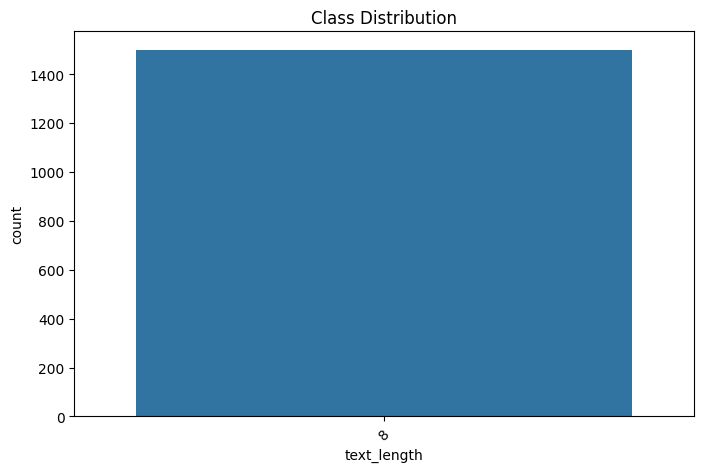

In [8]:
#Class Distribution Graph
plt.figure(figsize=(8,5))

sns.countplot(x=df.iloc[:, -1])

plt.title("Class Distribution")
plt.xticks(rotation=45)

plt.show()

# Task 1: Dataset Understanding

The dataset contains customer support text records along with their corresponding categories. The project represents a text classification problem where the goal is to classify customer queries into appropriate support categories.

In [9]:
#Text Preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df.iloc[:,0].apply(clean_text)

df[['clean_text']].head()

,clean_text
0,tkt
1,tkt
2,tkt
3,tkt
4,tkt


# Task 2: Text Preprocessing

The following preprocessing steps were applied:
- Converted text to lowercase
- Removed special characters and symbols
- Tokenized text into words
- Removed stopwords
- Prepared sequences for deep learning models

In [13]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text']).toarray()

y = df.iloc[:, 1]

# Task 3: Text Vectorization

Text data must be converted into numerical vectors because machine learning models cannot directly process raw text. TF-IDF converts text into numerical representations based on word importance within the dataset.

In [14]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
#Baseline Model
baseline_model = LogisticRegression()

baseline_model.fit(X_train, y_train)

LogisticRegression()

In [16]:
#Predictions
y_pred = baseline_model.predict(X_test)

In [17]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.20333333333333334


In [18]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         app       0.00      0.00      0.00        58
        chat       0.00      0.00      0.00        63
       email       0.20      1.00      0.34        61
       phone       0.00      0.00      0.00        67
      social       0.00      0.00      0.00        51

    accuracy                           0.20       300
   macro avg       0.04      0.20      0.07       300
weighted avg       0.04      0.20      0.07       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


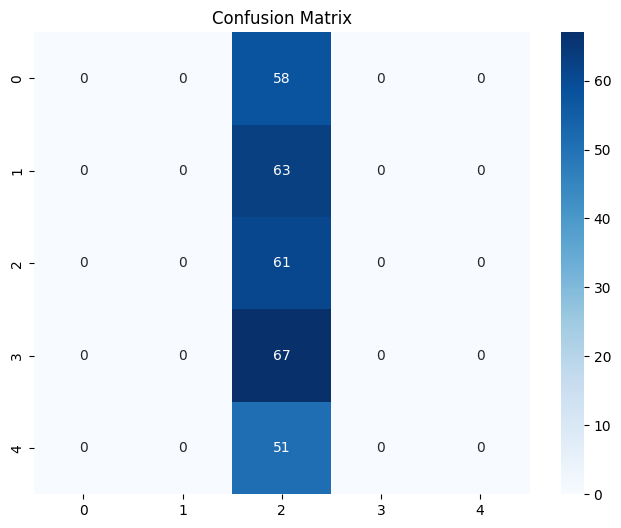

In [19]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.savefig("model_evaluation.png")

plt.show()

# Task 4: Baseline Model

A Logistic Regression model with TF-IDF vectorization was used as the baseline model for text classification. The model was evaluated using accuracy, confusion matrix, and classification metrics.

In [20]:
#Tokenizer Sequences
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

padded_sequences = pad_sequences(sequences, maxlen=100)

In [21]:
#Train Test Split for LSTM
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
#Encode Labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_seq = le.fit_transform(y_train_seq)
y_test_seq = le.transform(y_test_seq)

In [23]:
#Build LSTM Model
lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))

lstm_model.add(LSTM(64))

lstm_model.add(Dense(len(np.unique(y)), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
#Compile LSTM Model
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
#Train LSTM Model
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.2125 - loss: 1.6106 - val_accuracy: 0.1792 - val_loss: 1.6153
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.2313 - loss: 1.6064 - val_accuracy: 0.1792 - val_loss: 1.6130
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2313 - loss: 1.6066 - val_accuracy: 0.1792 - val_loss: 1.6128
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.2313 - loss: 1.6054 - val_accuracy: 0.1792 - val_loss: 1.6132
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2313 - loss: 1.6054 - val_accuracy: 0.1792 - val_loss: 1.6121


In [26]:
#Sample Predictions File
sample_predictions = baseline_model.predict(X_test[:10])

with open("sample_predictions.txt", "w") as f:
    for pred in sample_predictions:
        f.write(str(pred) + "\n")

print("Sample predictions saved.")

Sample predictions saved.


# Task 5: Sequence Model Architecture

The LSTM sequence model processes text in sequential order.

Architecture:
- Input sequence layer
- Embedding layer for word representation
- LSTM layer for sequence learning
- Dense output layer for classification

Loss Function:
- Sparse Categorical Crossentropy

Evaluation Metric:
- Accuracy
# Task 6: Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies
Traditional RNNs struggle to remember information from earlier parts of long sequences because gradients can vanish during training.

## How LSTMs Help with Memory
LSTMs use memory cells and gates to preserve important information over longer sequences.

## What Attention Solves
Attention mechanisms allow models to focus on the most relevant parts of the input sequence during prediction.

## Why Transformers Are Important
Transformers process sequences in parallel and use attention mechanisms, making them highly effective for modern NLP and Generative AI tasks.